In [2]:
import sys
sys.path.append("./models")
sys.path.append("./training")
sys.path.append("./testing")
sys.path.append("./utils")
sys.path.append("./ZuCo")
sys.path.append("./trainer")

In [3]:
# Import Pytorch
import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

# Import Pretrain Libraries (transformers + diffusers)
from transformers import BartTokenizer
from diffusers import AutoencoderKL

# Parallel Helper
from parallel import DataParallelModel, DataParallelCriterion

# Import Our Own Functions
from master_init import *
from DSG import *

from count_params import count_params

# Import Tasks
import EEG_TEXT_BART
import EEG_TEXT_BART_SENTIMENT
import EEG_IMG_DIFFUSION
import EEG_IMG_CLASSIFICATION
import PRETRAIN_EEG_IMG_CLIP_MATCHING
import PRETRAIN_EEG_TEXT_CLIP_MATCHING

In [4]:
torch.set_default_dtype(torch.float32)

# config = get_config() Implement later
config = {
    "device" : "cuda",
    "device_ids" : [0,1,2,3],
    "staging_device" : "cuda",
    "num_epochs" : 100,
    "use_non_pytorch_parallel" : False,
    "test_run" : False,
    "live_evaluate" : True,
    "eval_interval" : 1,
    "log_dir" : "./logs"
}

device = config["device"]
device_ids = config["device_ids"]
staging_device = config["staging_device"]
num_epochs = config["num_epochs"]
use_non_pytorch_parallel = config["use_non_pytorch_parallel"]
test_run = config["test_run"]
live_evaluate = config["live_evaluate"]
eval_interval = config["eval_interval"]
log_dir = config["log_dir"]

In [5]:
model = INITIALIZE_MODEL(device=None, device_ids=device_ids, dtype=torch.float32)
if use_non_pytorch_parallel:
    model = DataParallelModel(model).to(device)
else:
    model = nn.DataParallel(model, device_ids=device_ids).to(device)
dataset_dict = INITIALIZE_DATALOADERS(
    keys=["ZuCo-BART", "ZuCo-CLIP", "Brain2Image"],
    bsz=[256, 256, 1],
    dev_bsz=[256, 256, 1]
)

In [9]:
BART_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")

In [12]:
args_dict = {
        "model" : model,
        "dataloader" : dataset_dict["ZuCo-CLIP"],
        "optimizer" : optim.Adam(model.parameters(), lr=1e-5),
        "tokenizer" : BART_tokenizer,
        "criterion" : nn.KLDivLoss(reduction="batchmean"),
        "device" : device,
        "device_ids" : device_ids,
        "staging_device" : staging_device,
        "dev_bsz" : 256,
        "bool_eval" : True
    }

In [21]:
dataloader = args_dict["dataloader"]
model = args_dict["model"]
optimizer = args_dict["optimizer"]
tokenizer = args_dict["tokenizer"]
criterion = args_dict["criterion"]
device = args_dict["device"] if "device" in args_dict else "cuda"
device_ids = args_dict["device_ids"] if "device_ids" in args_dict else None
staging_device = args_dict["staging_device"] if "staging_device" in args_dict else None
dev_bsz = args_dict["dev_bsz"] if "dev_bsz" in args_dict else 64
bool_eval = args_dict["bool_eval"] if "bool_eval" in args_dict else False
symmetric_KL = lambda a, b, t=1: 0.5 * (criterion(F.log_softmax(a/t, dim=1), F.softmax(b/t, dim=1)) + criterion(F.log_softmax(b/t, dim=1), F.softmax(a/t, dim=1)))
temperature = args_dict["temperature"] if "temperature" in args_dict else 0.07

In [22]:
current_data = dataloader["train"].load_data()

In [23]:
input_embeddings, seq_len, input_masks, input_mask_invert, target_ids, target_mask, sentiment_labels, sent_level_EEG = current_data["data"]

input_embeddings_batch = input_embeddings
input_masks_batch = input_masks
input_mask_invert_batch = input_mask_invert
target_ids_batch = target_ids

"""replace padding ids in target_ids with -100"""
target_ids_batch[target_ids_batch == tokenizer.pad_token_id] = -100

optimizer.zero_grad()

args_dict = {
    "input_data_batch" : input_embeddings_batch.to(staging_device, dtype=torch.float32),
    "input_masks_batch" : input_masks_batch.to(staging_device, dtype=torch.float32),
    "input_masks_invert" : input_mask_invert_batch.to(staging_device, dtype=torch.float32),
    "target_ids_batch" : target_ids_batch.to(staging_device),
    "pool_result" : False
    }

output = model(
    mode="PRETRAIN-EEG-TEXT-CLIP-MATCHING",
    args_dict=args_dict,
    staging_device=staging_device,
)

In [24]:
target_embed = current_data["target"].to(torch.float32)
target_embeds_pooled = torch.mean(target_embed, dim=1)
target_pairwise_embeds = torch.mm(target_embeds_pooled, target_embeds_pooled.T)

output = torch.mean(output, dim=1).to(torch.float32)
output = torch.mm(output, target_embeds_pooled.T)

In [32]:
new_output = F.softmax(output/temperature, dim=1)

In [110]:
new_output

tensor([[3.0807e-05, 1.3649e-42, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.9699e-33, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.6027e-13, 5.6052e-45, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [2.6330e-25, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.5989e-15, 5.4651e-44, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [9.2960e-26, 6.5909e-40, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [111]:
np_output = new_output.detach().cpu().numpy()

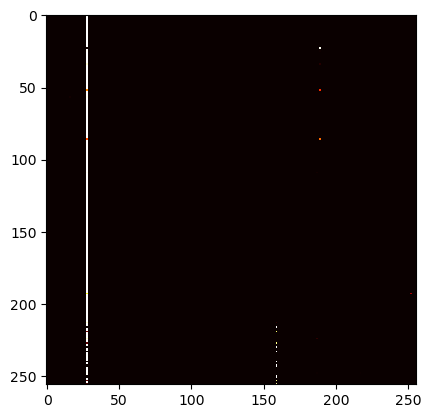

In [112]:
import matplotlib.pyplot as plt

plt.imshow(np_output, cmap='hot', interpolation='nearest')
plt.show()

In [170]:
temp = 20

In [171]:
new_target = F.softmax(target_pairwise_embeds/temp, dim=1)
np_target = new_target.detach().cpu().numpy()

In [172]:
new_target.shape

torch.Size([256, 256])

In [173]:
new_target[:4,:4]

tensor([[9.9988e-01, 4.9364e-11, 1.2239e-09, 2.5529e-08],
        [1.2800e-05, 9.9503e-01, 1.6381e-05, 7.9103e-06],
        [3.2147e-08, 1.6593e-09, 9.9794e-01, 2.6301e-07],
        [5.9168e-06, 7.0704e-09, 2.3208e-06, 9.9088e-01]], device='cuda:0')

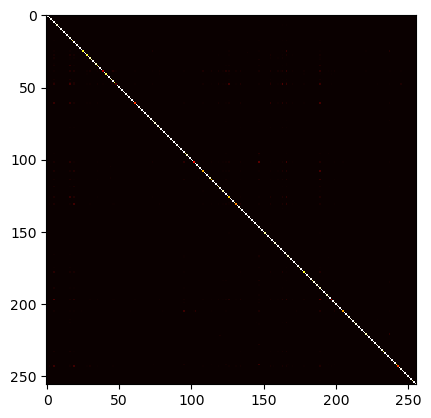

In [174]:
plt.imshow(np_target, cmap='hot', interpolation='nearest')
plt.show()

In [175]:
[np_target[i][i] for i in range(256)]

[0.9998766,
 0.9950336,
 0.9979386,
 0.9908806,
 0.9954716,
 0.99567395,
 0.9793788,
 0.96284354,
 0.9999858,
 0.99980575,
 0.9924253,
 0.983548,
 0.999959,
 0.9999299,
 0.999894,
 0.99948007,
 0.9830157,
 0.99974614,
 0.84760785,
 0.9975097,
 0.9866831,
 0.99989617,
 0.99972993,
 0.9980939,
 0.9996371,
 0.7858947,
 0.96598256,
 0.9979365,
 0.8076134,
 0.99999917,
 0.9163914,
 0.9145704,
 0.9999999,
 0.99997866,
 0.95196986,
 0.8061736,
 0.999592,
 0.99960107,
 0.99990463,
 0.26811594,
 0.9981634,
 0.831059,
 0.9967368,
 0.99888355,
 0.9998129,
 0.8959637,
 0.99870706,
 0.7995324,
 0.11363873,
 0.9996388,
 0.99469334,
 0.99997747,
 0.99821305,
 0.9999349,
 0.9992244,
 0.9897962,
 0.9963431,
 0.99714905,
 0.99438804,
 0.9999405,
 0.9999757,
 0.44711325,
 1.0,
 0.9999999,
 0.9995865,
 0.98327315,
 0.9997601,
 0.99993193,
 0.99997854,
 0.99965405,
 0.99785763,
 0.96564215,
 0.9999716,
 0.96966064,
 0.95590776,
 0.9615829,
 0.9655218,
 0.99999547,
 0.91403687,
 0.99982506,
 0.9998752,
 0.9